# CBIR Evaluation Notebook

This notebook compares CBIR Method 1 and CBIR Method 2 on the same held-out test split.

Workflow:
1. Load the shared split file created by the training notebooks.
2. Build method-specific in-memory galleries from split `gallery` images.
3. Evaluate both methods on split `test` images.
4. Report side-by-side metrics and confusion matrices.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json
import importlib
import sys
import builtins

builtins.quit = sys.exit

import cv2
import numpy as np
from numpy.typing import NDArray
import scipy.spatial.distance as sp_distance
import face_recognition
import matplotlib.pyplot as plt

pd = importlib.import_module("pandas")
sns = importlib.import_module("seaborn")

ImageArray = NDArray[np.uint8]
FloatArray = NDArray[np.float32]

project_root: Path = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

FACE_DIR: Path = project_root / "data" / "face"
MODELS_DIR: Path = project_root / "models"
EVAL_OUTPUT_DIR: Path = MODELS_DIR / "evaluation"
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_PATH: Path = MODELS_DIR / "cbir_eval_split.json"

METHODS: dict[str, dict[str, Any]] = {
    "cbir_method1": {
        "meta_path": MODELS_DIR / "cbir_method1_meta.json",
        "threshold": 0.60,
        "strict_unknown_threshold": 0.72,
        "min_margin": 0.035,
    },
    "cbir_method2": {
        "meta_path": MODELS_DIR / "cbir_method2_meta.json",
        "threshold": 0.60,
        "strict_unknown_threshold": 0.72,
        "min_margin": 0.035,
    },
}
UNKNOWN_LABEL = "unknown"
sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {project_root}")
print(f"Split path  : {SPLIT_PATH}")
print(f"Eval outputs: {EVAL_OUTPUT_DIR}")

c:\Users\harry\Documents\school\ip\AttSystem\.venv\Lib\site-packages\face_recognition_models\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Project root: c:\Users\harry\Documents\school\ip\AttSystem
Split path  : c:\Users\harry\Documents\school\ip\AttSystem\models\cbir_eval_split.json
Eval outputs: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation


In [2]:
haar_root = Path(getattr(cv2, "data").haarcascades)  # type: ignore[attr-defined]
face_cascade = cv2.CascadeClassifier(str(haar_root / "haarcascade_frontalface_default.xml"))
if face_cascade.empty():
    raise RuntimeError("Failed to load OpenCV frontal face cascade.")


def detect_face_roi(gray: ImageArray) -> ImageArray:
    h, w = gray.shape[:2]
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40),
    )

    if len(faces) == 0:
        side: int = int(min(h, w) * 0.75)
        cx, cy = w // 2, h // 2
        x1: int = max(0, cx - side // 2)
        y1: int = max(0, cy - side // 2)
        x2: int = min(w, x1 + side)
        y2: int = min(h, y1 + side)
        return gray[y1:y2, x1:x2].astype(np.uint8, copy=False)

    x, y, fw, fh = max(faces, key=lambda f: int(f[2]) * int(f[3]))
    pad_w: int = int(fw * 0.2)
    pad_h: int = int(fh * 0.2)

    x1: int = max(0, int(x) - pad_w)
    y1: int = max(0, int(y) - pad_h)
    x2: int = min(w, int(x) + int(fw) + pad_w)
    y2: int = min(h, int(y) + int(fh) + pad_h)

    return gray[y1:y2, x1:x2].astype(np.uint8, copy=False)


def preprocess_roi_method1(roi_gray: ImageArray, output_size: tuple[int, int] = (128, 128)) -> ImageArray:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(roi_gray)
    enhanced = cv2.GaussianBlur(enhanced, (3, 3), 0)
    resized = cv2.resize(enhanced, output_size, interpolation=cv2.INTER_CUBIC)
    return resized.astype(np.uint8, copy=False)


def preprocess_roi_method2(roi_gray: ImageArray, output_size: tuple[int, int] = (128, 128)) -> ImageArray:
    equalized = cv2.equalizeHist(roi_gray)
    denoised = cv2.bilateralFilter(equalized, d=7, sigmaColor=50, sigmaSpace=50)
    sharpened = cv2.addWeighted(
        denoised,
        1.35,
        cv2.GaussianBlur(denoised, (0, 0), 1.2),
        -0.35,
        0,
    )
    resized = cv2.resize(sharpened, output_size, interpolation=cv2.INTER_CUBIC)
    return resized.astype(np.uint8, copy=False)


def extract_embedding_from_face(face_gray: ImageArray) -> FloatArray | None:
    face_rgb = cv2.cvtColor(face_gray, cv2.COLOR_GRAY2RGB)
    encodings: list[Any] = face_recognition.face_encodings(face_rgb)
    if len(encodings) == 0:
        return None

    emb = np.array(encodings[0], dtype=np.float32)
    norm = np.linalg.norm(emb)
    if norm <= 1e-12:
        return None
    return (emb / norm).astype(np.float32)

In [3]:
def load_split(path: Path) -> dict[str, dict[str, list[str]]]:
    if not path.exists():
        raise FileNotFoundError(
            f"Split file not found at {path}. Run cbir_method1 and cbir_method2 notebooks first."
        )

    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    identities = payload.get("identities", payload)
    split_data: dict[str, dict[str, list[str]]] = {}
    for person, parts in identities.items():
        if not isinstance(parts, dict):
            continue
        split_data[str(person)] = {
            "gallery": [str(x) for x in parts.get("gallery", [])],
            "test": [str(x) for x in parts.get("test", [])],
        }
    return split_data


def load_method_thresholds(meta_path: Path) -> dict[str, float]:
    if not meta_path.exists():
        return {}
    with meta_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)
    return {
        "threshold": float(meta.get("similarity_threshold", meta.get("threshold", 0.60))),
        "strict_unknown_threshold": float(meta.get("similarity_strict_unknown_threshold", 0.72)),
        "min_margin": float(meta.get("similarity_min_margin", 0.035)),
    }


def collect_person_files(face_dir: Path) -> dict[str, list[Path]]:
    if not face_dir.exists() or not face_dir.is_dir():
        raise FileNotFoundError(f"Missing dataset folder: {face_dir}")

    out: dict[str, list[Path]] = {}
    for person_dir in sorted([p for p in face_dir.iterdir() if p.is_dir()]):
        files = sorted(
            [
                p
                for p in person_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
            ]
        )
        if files:
            out[person_dir.name] = files
    return out


def preprocess_by_method(gray: ImageArray, method_name: str, output_size: tuple[int, int] = (128, 128)) -> ImageArray:
    roi = detect_face_roi(gray)
    if roi.size == 0:
        return roi

    if method_name == "cbir_method2":
        return preprocess_roi_method2(roi, output_size=output_size)
    return preprocess_roi_method1(roi, output_size=output_size)


def build_gallery_embeddings(
    person_files: dict[str, list[Path]],
    split_data: dict[str, dict[str, list[str]]],
    method_name: str,
) -> tuple[FloatArray, NDArray[np.int32], dict[int, str], dict[str, int]]:
    embeddings: list[FloatArray] = []
    labels: list[int] = []
    id_to_name: dict[int, str] = {}
    name_to_id: dict[str, int] = {}

    label_counter = 0
    for person_name in sorted(person_files.keys()):
        selected = set(split_data.get(person_name, {}).get("gallery", []))
        gallery_files = [p for p in person_files[person_name] if p.name in selected]
        if not gallery_files:
            continue

        name_to_id[person_name] = label_counter
        id_to_name[label_counter] = person_name

        kept = 0
        for path in gallery_files:
            bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
            if bgr is None:
                continue
            gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.uint8, copy=False)
            sample = preprocess_by_method(gray, method_name, output_size=(128, 128))
            if sample.size == 0:
                continue

            emb = extract_embedding_from_face(sample)
            if emb is None:
                continue

            embeddings.append(emb)
            labels.append(label_counter)
            kept += 1

        print(f"[{method_name}] {person_name}: gallery embeddings {kept}/{len(gallery_files)}")
        if kept > 0:
            label_counter += 1
        else:
            del name_to_id[person_name]
            del id_to_name[label_counter]

    if not embeddings:
        raise RuntimeError(f"No gallery embeddings produced for {method_name}.")

    emb_np: FloatArray = np.vstack(embeddings).astype(np.float32)
    label_np: NDArray[np.int32] = np.array(labels, dtype=np.int32)
    return emb_np, label_np, id_to_name, name_to_id

In [4]:
def predict_identity(
    query_embedding: FloatArray,
    gallery_embeddings: FloatArray,
    gallery_labels: NDArray[np.int32],
    id_to_name: dict[int, str],
    threshold: float,
    strict_unknown_threshold: float,
    min_margin: float,
) -> tuple[str, float, float, bool]:
    distances = sp_distance.cdist([query_embedding], gallery_embeddings, metric="cosine")[0]
    order = np.argsort(distances)
    best_idx = int(order[0])

    best_distance = float(distances[best_idx])
    best_similarity = 1.0 - best_distance
    best_label_id = int(gallery_labels[best_idx])
    raw_pred = id_to_name.get(best_label_id, UNKNOWN_LABEL)

    other_mask = gallery_labels != best_label_id
    if np.any(other_mask):
        second_distance = float(np.min(distances[other_mask]))
    else:
        second_distance = 1.0
    second_similarity = 1.0 - second_distance
    margin = max(0.0, best_similarity - second_similarity)

    accepted = (
        best_similarity >= threshold
        and best_similarity >= strict_unknown_threshold
        and margin >= min_margin
    )
    pred_label = raw_pred if accepted else UNKNOWN_LABEL
    return pred_label, best_similarity, margin, accepted


def compute_micro_precision_recall(y_true: list[str], y_pred: list[str], unknown_label: str) -> tuple[float, float]:
    known_true = [t for t in y_true if t != unknown_label]
    if not known_true:
        return float("nan"), float("nan")

    tp = 0
    fp = 0
    fn = 0
    for t, p in zip(y_true, y_pred):
        t_known = t != unknown_label
        p_known = p != unknown_label

        if t_known and p_known and t == p:
            tp += 1
        elif (not t_known) and p_known:
            fp += 1
        elif t_known and (not p_known):
            fn += 1
        elif t_known and p_known and t != p:
            fp += 1
            fn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    return precision, recall


def evaluate_method(
    method_name: str,
    person_files: dict[str, list[Path]],
    split_data: dict[str, dict[str, list[str]]],
    unknown_people: list[str],
) -> dict[str, Any]:
    thresholds = METHODS[method_name].copy()
    loaded = load_method_thresholds(METHODS[method_name]["meta_path"])
    thresholds.update(loaded)

    threshold = float(thresholds["threshold"])
    strict_unknown_threshold = float(thresholds["strict_unknown_threshold"])
    min_margin = float(thresholds["min_margin"])

    gallery_embeddings, gallery_labels, id_to_name, name_to_id = build_gallery_embeddings(
        person_files,
        split_data,
        method_name,
    )

    y_true: list[str] = []
    y_pred: list[str] = []
    known_total = 0
    known_correct = 0
    unknown_total = 0
    unknown_correct = 0
    evaluated = 0

    for person_name in sorted(person_files.keys()):
        test_names = set(split_data.get(person_name, {}).get("test", []))
        test_files = [p for p in person_files[person_name] if p.name in test_names]
        if not test_files:
            continue

        is_unknown_identity = person_name in unknown_people
        for path in test_files:
            bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
            if bgr is None:
                continue

            gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.uint8, copy=False)
            sample = preprocess_by_method(gray, method_name, output_size=(128, 128))
            if sample.size == 0:
                continue

            emb = extract_embedding_from_face(sample)
            if emb is None:
                continue

            if is_unknown_identity:
                true_label = UNKNOWN_LABEL
            else:
                true_label = person_name if person_name in name_to_id else UNKNOWN_LABEL

            pred_label, _, _, _ = predict_identity(
                emb,
                gallery_embeddings,
                gallery_labels,
                id_to_name,
                threshold=threshold,
                strict_unknown_threshold=strict_unknown_threshold,
                min_margin=min_margin,
            )

            y_true.append(true_label)
            y_pred.append(pred_label)
            evaluated += 1

            if true_label == UNKNOWN_LABEL:
                unknown_total += 1
                if pred_label == UNKNOWN_LABEL:
                    unknown_correct += 1
            else:
                known_total += 1
                if pred_label == true_label:
                    known_correct += 1

    if evaluated == 0:
        raise RuntimeError(f"No evaluable test samples for {method_name}. Check split file and images.")

    overall_acc = sum(1 for t, p in zip(y_true, y_pred) if t == p) / evaluated
    known_acc = (known_correct / known_total) if known_total else float("nan")
    unknown_reject = (unknown_correct / unknown_total) if unknown_total else float("nan")
    precision, recall = compute_micro_precision_recall(y_true, y_pred, UNKNOWN_LABEL)
    f1 = (2.0 * precision * recall / (precision + recall)) if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0 else float("nan")

    return {
        "method": method_name,
        "threshold": threshold,
        "strict_unknown_threshold": strict_unknown_threshold,
        "min_margin": min_margin,
        "num_gallery_vectors": int(gallery_embeddings.shape[0]),
        "num_eval_samples": evaluated,
        "known_samples": known_total,
        "unknown_samples": unknown_total,
        "overall_accuracy": overall_acc,
        "known_accuracy": known_acc,
        "unknown_reject_rate": unknown_reject,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "labels": sorted(set(y_true) | set(y_pred)),
    }

In [5]:
def build_confusion_matrix(
    y_true: list[str],
    y_pred: list[str],
    labels: list[str],
) -> NDArray[np.int32]:
    idx = {label: i for i, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int32)
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    return cm


def print_confusion_matrix(cm: NDArray[np.int32], labels: list[str], title: str) -> None:
    print()
    print(title)
    header = "true\\pred".ljust(16) + " ".join(label[:12].ljust(12) for label in labels)
    print(header)
    for i, label in enumerate(labels):
        row = label[:12].ljust(16) + " ".join(str(int(v)).ljust(12) for v in cm[i])
        print(row)


split_data = load_split(SPLIT_PATH)
person_files = collect_person_files(FACE_DIR)

# Unknown identities are those with no gallery images and at least one test image.
unknown_people = [
    person
    for person, parts in split_data.items()
    if len(parts.get("gallery", [])) == 0 and len(parts.get("test", [])) > 0
]

print(f"Total identities in split: {len(split_data)}")
print(f"Unknown-only identities: {len(unknown_people)}")

Total identities in split: 21
Unknown-only identities: 0


In [6]:
results = []
for method_name in ["cbir_method1", "cbir_method2"]:
    print()
    print(f"Evaluating {method_name} ...")
    metrics = evaluate_method(
        method_name=method_name,
        person_files=person_files,
        split_data=split_data,
        unknown_people=unknown_people,
    )
    results.append(metrics)

for m in results:
    print()
    print(f"Method: {m['method']}")
    print(f"  Gallery vectors       : {m['num_gallery_vectors']}")
    print(f"  Evaluated samples     : {m['num_eval_samples']}")
    print(f"  Known samples         : {m['known_samples']}")
    print(f"  Unknown samples       : {m['unknown_samples']}")
    print(f"  Overall accuracy      : {m['overall_accuracy']:.4f}")
    print(f"  Known accuracy        : {m['known_accuracy']:.4f}" if not np.isnan(m['known_accuracy']) else "  Known accuracy        : n/a")
    print(f"  Unknown reject rate   : {m['unknown_reject_rate']:.4f}" if not np.isnan(m['unknown_reject_rate']) else "  Unknown reject rate   : n/a")
    print(f"  Precision (micro)     : {m['precision']:.4f}" if not np.isnan(m['precision']) else "  Precision (micro)     : n/a")
    print(f"  Recall (micro)        : {m['recall']:.4f}" if not np.isnan(m['recall']) else "  Recall (micro)        : n/a")
    print(f"  F1 score (micro)      : {m['f1_score']:.4f}" if not np.isnan(m['f1_score']) else "  F1 score (micro)      : n/a")
    print(f"  Threshold             : {m['threshold']:.4f}")
    print(f"  Strict unknown thr    : {m['strict_unknown_threshold']:.4f}")
    print(f"  Min margin            : {m['min_margin']:.4f}")

best = max(results, key=lambda x: x["overall_accuracy"])
print()
print(f"Best overall accuracy: {best['method']} ({best['overall_accuracy']:.4f})")


Evaluating cbir_method1 ...
[cbir_method1] benjamin: gallery embeddings 469/864
[cbir_method1] chern_tak: gallery embeddings 805/806
[cbir_method1] chillien: gallery embeddings 112/259
[cbir_method1] daniel: gallery embeddings 680/864
[cbir_method1] dylan: gallery embeddings 312/605
[cbir_method1] han_soon: gallery embeddings 384/576
[cbir_method1] harry: gallery embeddings 281/288
[cbir_method1] isaac: gallery embeddings 33/288
[cbir_method1] jing_ang: gallery embeddings 650/864
[cbir_method1] jun_wei: gallery embeddings 715/778
[cbir_method1] kang_kai: gallery embeddings 839/864
[cbir_method1] marion: gallery embeddings 600/806
[cbir_method1] ms_nurul: gallery embeddings 297/317
[cbir_method1] qi_xuan: gallery embeddings 838/864
[cbir_method1] shuang_quan: gallery embeddings 1161/1296
[cbir_method1] wee_xuan: gallery embeddings 636/691
[cbir_method1] xiang_yue: gallery embeddings 841/864
[cbir_method1] xu_sheng: gallery embeddings 820/835
[cbir_method1] yoke_hong: gallery embeddings

In [7]:
summary_rows: list[dict[str, Any]] = []
for item in results:
    summary_rows.append(
        {
            "method": item["method"],
            "gallery_vectors": item["num_gallery_vectors"],
            "eval_samples": item["num_eval_samples"],
            "known_samples": item["known_samples"],
            "unknown_samples": item["unknown_samples"],
            "overall_accuracy": item["overall_accuracy"],
            "known_accuracy": item["known_accuracy"],
            "unknown_reject_rate": item["unknown_reject_rate"],
            "precision": item["precision"],
            "recall": item["recall"],
            "f1_score": item["f1_score"],
            "threshold": item["threshold"],
            "strict_unknown_threshold": item["strict_unknown_threshold"],
            "min_margin": item["min_margin"],
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("overall_accuracy", ascending=False).reset_index(drop=True)
summary_df_rounded = summary_df.copy()
for col in [
    "overall_accuracy",
    "known_accuracy",
    "unknown_reject_rate",
    "precision",
    "recall",
    "f1_score",
    "threshold",
    "strict_unknown_threshold",
    "min_margin",
]:
    summary_df_rounded[col] = summary_df_rounded[col].astype(float).round(4)

display(summary_df_rounded)

summary_csv_path = EVAL_OUTPUT_DIR / "method_comparison_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)
print(f"Saved summary table: {summary_csv_path}")

,method,gallery_vectors,eval_samples,known_samples,unknown_samples,overall_accuracy,known_accuracy,unknown_reject_rate,precision,recall,f1_score,threshold,strict_unknown_threshold,min_margin
0,cbir_method2,11341,2834,2834,0,0.8733,0.8733,NaN,1.0,0.8733,0.9324,0.6,0.72,0.035
1,cbir_method1,11653,2913,2913,0,0.6038,0.6038,NaN,1.0,0.6038,0.7530,0.6,0.72,0.035


Saved summary table: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\method_comparison_summary.csv


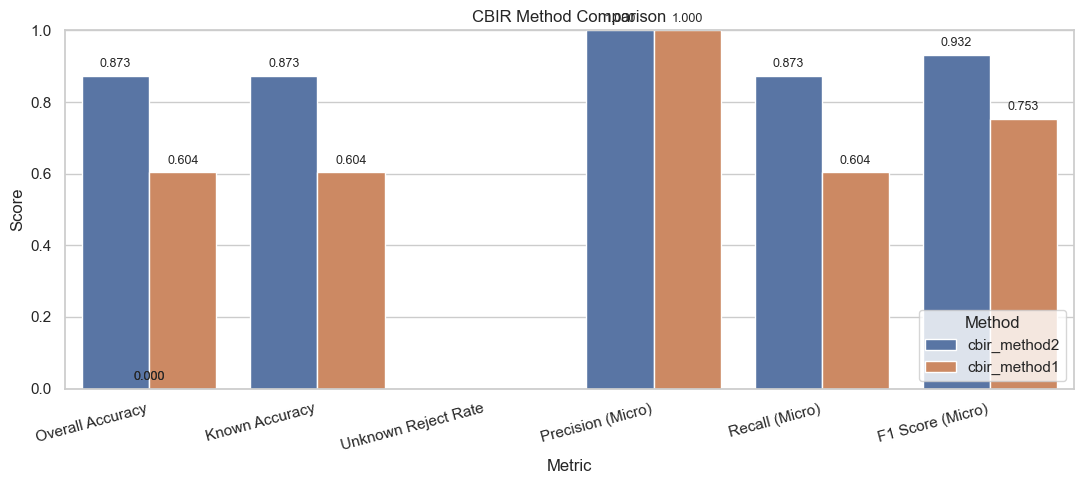

Saved chart: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\metric_comparison_bar.png


In [8]:
metrics_for_chart = ["overall_accuracy", "known_accuracy", "unknown_reject_rate", "precision", "recall", "f1_score"]
chart_df = summary_df[["method"] + metrics_for_chart].melt(
    id_vars=["method"],
    value_vars=metrics_for_chart,
    var_name="metric",
    value_name="value",
)

metric_name_map = {
    "overall_accuracy": "Overall Accuracy",
    "known_accuracy": "Known Accuracy",
    "unknown_reject_rate": "Unknown Reject Rate",
    "precision": "Precision (Micro)",
    "recall": "Recall (Micro)",
    "f1_score": "F1 Score (Micro)",
}
chart_df["metric"] = chart_df["metric"].map(metric_name_map)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=chart_df, x="metric", y="value", hue="method")
ax.set_title("CBIR Method Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.0)
ax.legend(title="Method", loc="lower right")

for patch in ax.patches:
    patch_any: Any = patch
    height = float(patch_any.get_height())
    if np.isfinite(height):
        ax.annotate(
            f"{height:.3f}",
            (float(patch_any.get_x()) + float(patch_any.get_width()) / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 4),
            textcoords="offset points",
        )

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
metric_chart_path = EVAL_OUTPUT_DIR / "metric_comparison_bar.png"
plt.savefig(metric_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved chart: {metric_chart_path}")

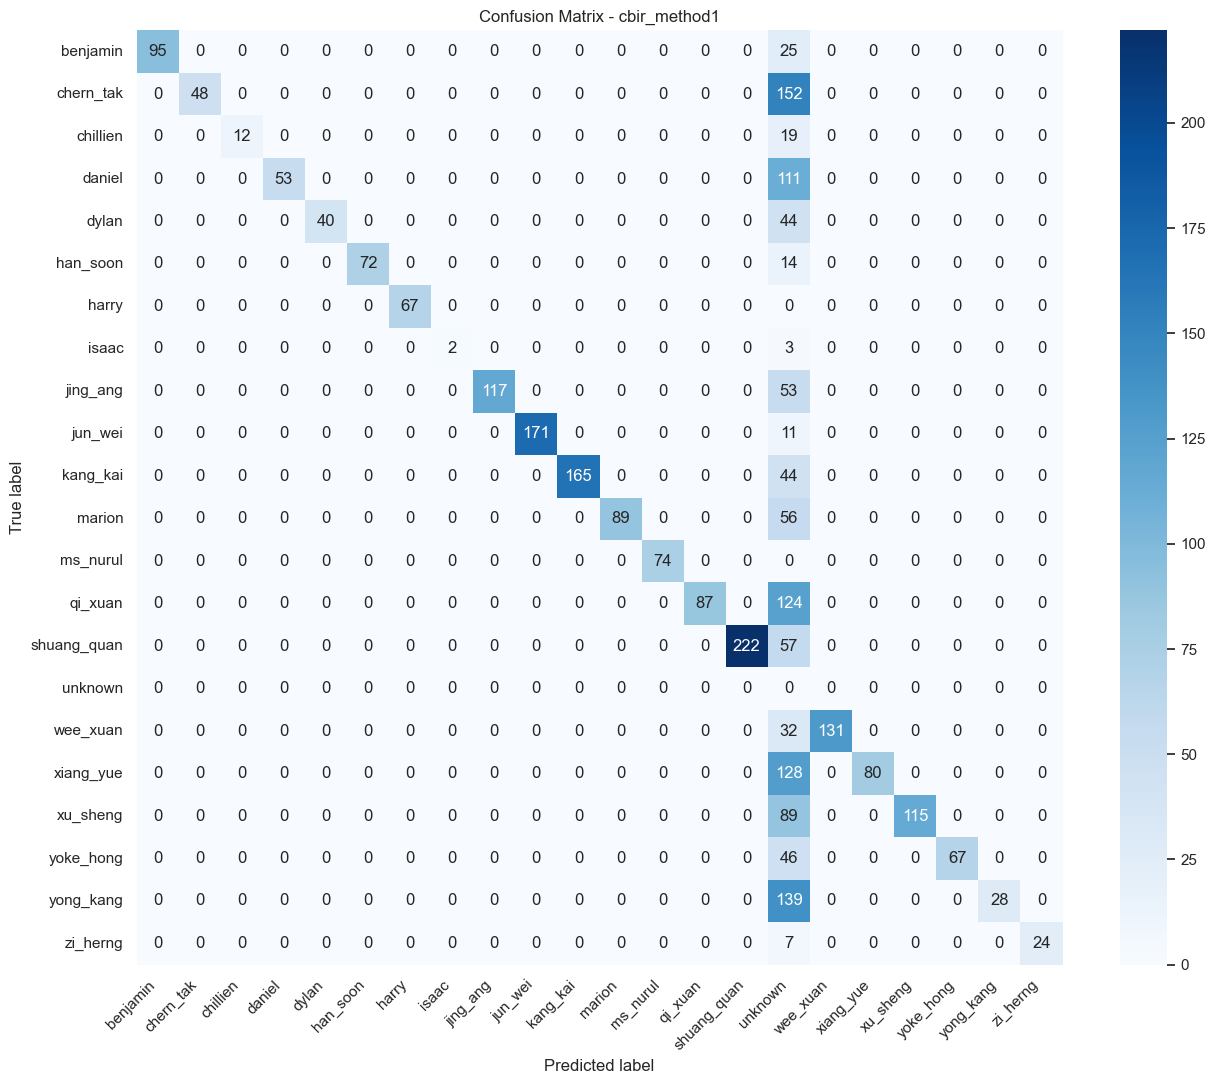

Saved confusion matrix: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\confusion_matrix_cbir_method1.png


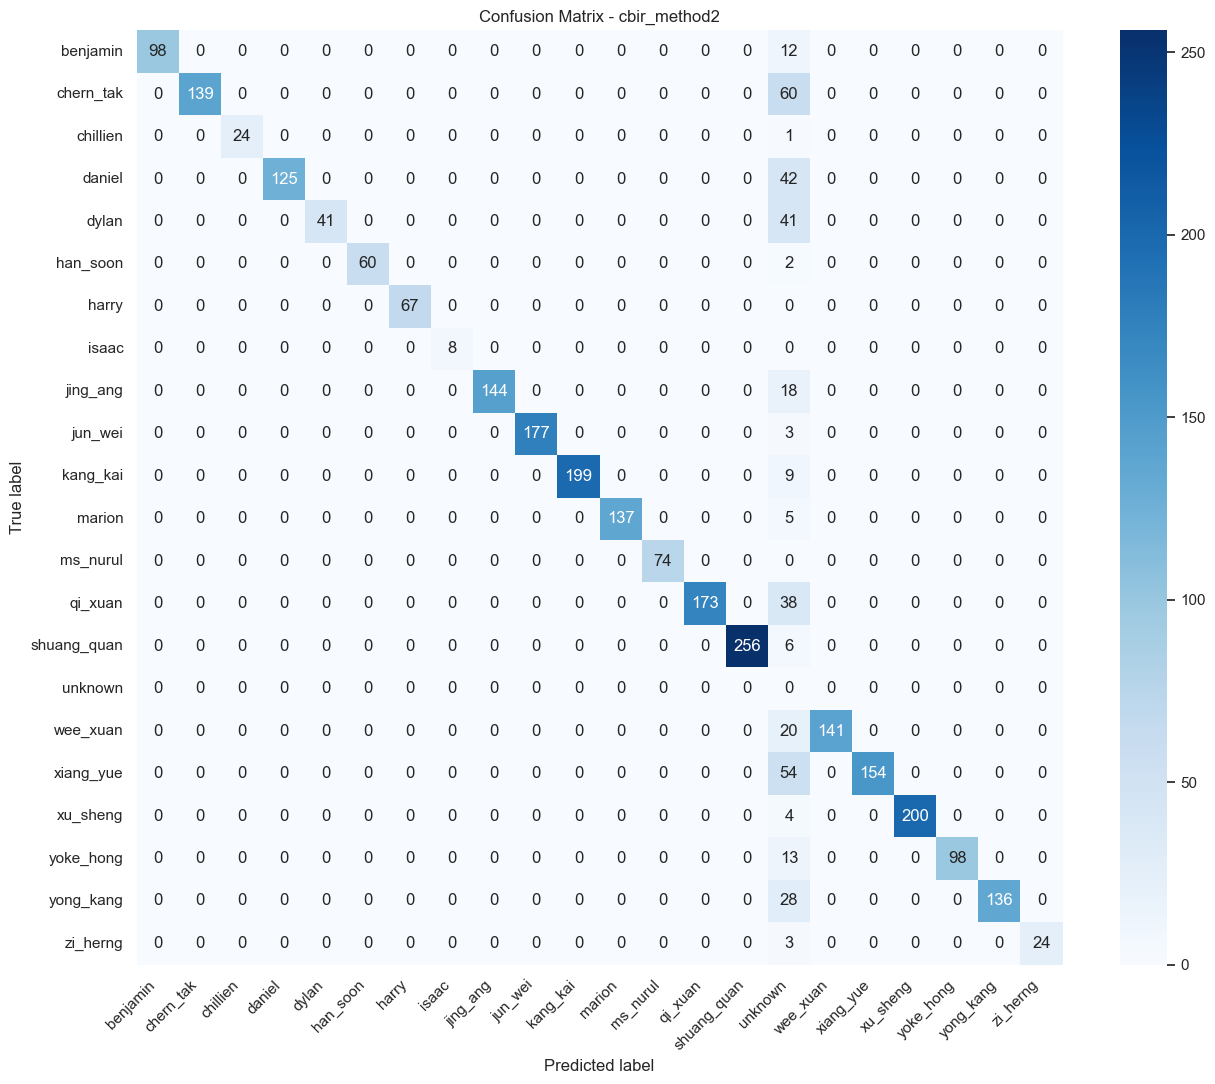

Saved confusion matrix: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\confusion_matrix_cbir_method2.png


In [9]:
for item in results:
    labels = item["labels"]
    cm = build_confusion_matrix(item["y_true"], item["y_pred"], labels)

    fig, ax = plt.subplots(figsize=(max(7, len(labels) * 0.6), max(5, len(labels) * 0.5)))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {item['method']}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    cm_path = EVAL_OUTPUT_DIR / f"confusion_matrix_{item['method']}.png"
    plt.savefig(cm_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved confusion matrix: {cm_path}")

C:\Users\harry\AppData\Local\Temp\ipykernel_11400\397013622.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=worst_df, x="accuracy", y="identity", orient="h", palette="rocket")


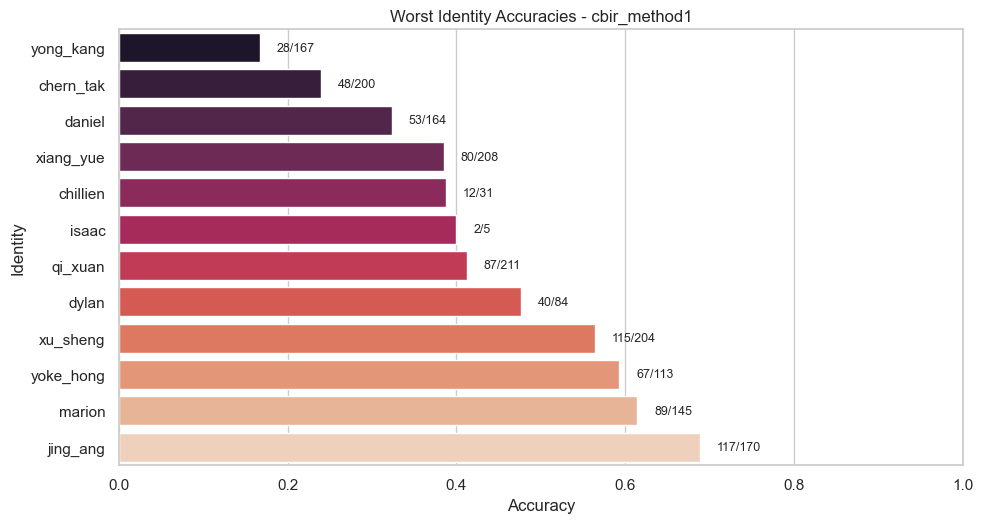

Saved per-identity chart: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\worst_identities_cbir_method1.png
Saved per-identity table: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\per_identity_accuracy_cbir_method1.csv


C:\Users\harry\AppData\Local\Temp\ipykernel_11400\397013622.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=worst_df, x="accuracy", y="identity", orient="h", palette="rocket")


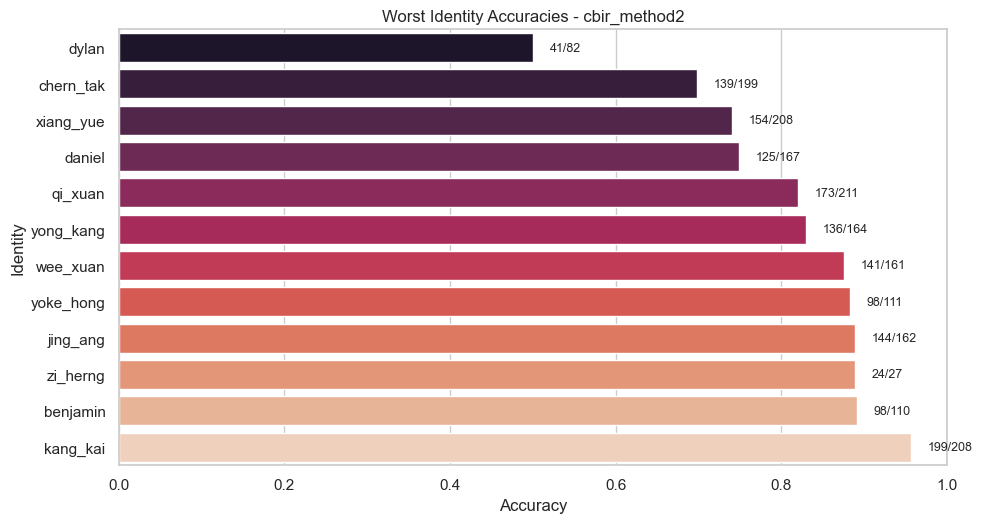

Saved per-identity chart: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\worst_identities_cbir_method2.png
Saved per-identity table: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\per_identity_accuracy_cbir_method2.csv


In [10]:
def per_identity_accuracy(y_true: list[str], y_pred: list[str]):
    counters: dict[str, dict[str, int]] = {}
    for t, p in zip(y_true, y_pred):
        if t == UNKNOWN_LABEL:
            continue
        if t not in counters:
            counters[t] = {"total": 0, "correct": 0}
        counters[t]["total"] += 1
        if t == p:
            counters[t]["correct"] += 1

    rows = []
    for person, info in counters.items():
        total = info["total"]
        correct = info["correct"]
        acc = (correct / total) if total else float("nan")
        rows.append({"identity": person, "samples": total, "correct": correct, "accuracy": acc})

    return pd.DataFrame(rows).sort_values(["accuracy", "samples"], ascending=[True, False])


for item in results:
    pid_df = per_identity_accuracy(item["y_true"], item["y_pred"])
    if pid_df.empty:
        print(f"No per-identity rows for {item['method']}.")
        continue

    top_n = min(12, len(pid_df))
    worst_df = pid_df.head(top_n).sort_values("accuracy", ascending=True)

    plt.figure(figsize=(10, max(4, top_n * 0.45)))
    ax = sns.barplot(data=worst_df, x="accuracy", y="identity", orient="h", palette="rocket")
    ax.set_title(f"Worst Identity Accuracies - {item['method']}")
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Identity")
    for i, (_, row) in enumerate(worst_df.iterrows()):
        ax.text(
            min(0.98, float(row['accuracy']) + 0.02),
            i,
            f"{int(row['correct'])}/{int(row['samples'])}",
            va="center",
            fontsize=9,
        )
    plt.tight_layout()

    out_path = EVAL_OUTPUT_DIR / f"worst_identities_{item['method']}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved per-identity chart: {out_path}")

    pid_csv = EVAL_OUTPUT_DIR / f"per_identity_accuracy_{item['method']}.csv"
    pid_df.to_csv(pid_csv, index=False)
    print(f"Saved per-identity table: {pid_csv}")

In [11]:
def top_confusions(y_true: list[str], y_pred: list[str], top_k: int = 15):
    confusion_counts: dict[tuple[str, str], int] = {}
    for t, p in zip(y_true, y_pred):
        if t == p:
            continue
        key = (t, p)
        confusion_counts[key] = confusion_counts.get(key, 0) + 1

    if not confusion_counts:
        return pd.DataFrame(columns=["true_label", "predicted_label", "count"])

    rows = [
        {"true_label": t, "predicted_label": p, "count": c}
        for (t, p), c in confusion_counts.items()
    ]
    df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    return df.head(top_k)


error_rows = []
for item in results:
    df = top_confusions(item["y_true"], item["y_pred"], top_k=20)
    if df.empty:
        print(f"No misclassifications found for {item['method']}.")
        continue
    df.insert(0, "method", item["method"])
    error_rows.append(df)
    print()
    print(f"Top confusions for {item['method']}")
    display(df)

if error_rows:
    combined_errors = pd.concat(error_rows, ignore_index=True)
    errors_csv = EVAL_OUTPUT_DIR / "top_confusions.csv"
    combined_errors.to_csv(errors_csv, index=False)
    print(f"Saved error table: {errors_csv}")


Top confusions for cbir_method1


,method,true_label,predicted_label,count
0,cbir_method1,chern_tak,unknown,152
1,cbir_method1,yong_kang,unknown,139
2,cbir_method1,xiang_yue,unknown,128
3,cbir_method1,qi_xuan,unknown,124
4,cbir_method1,daniel,unknown,111
5,cbir_method1,xu_sheng,unknown,89
6,cbir_method1,shuang_quan,unknown,57
7,cbir_method1,marion,unknown,56
8,cbir_method1,jing_ang,unknown,53
9,cbir_method1,yoke_hong,unknown,46



Top confusions for cbir_method2


,method,true_label,predicted_label,count
0,cbir_method2,chern_tak,unknown,60
1,cbir_method2,xiang_yue,unknown,54
2,cbir_method2,daniel,unknown,42
3,cbir_method2,dylan,unknown,41
4,cbir_method2,qi_xuan,unknown,38
5,cbir_method2,yong_kang,unknown,28
6,cbir_method2,wee_xuan,unknown,20
7,cbir_method2,jing_ang,unknown,18
8,cbir_method2,yoke_hong,unknown,13
9,cbir_method2,benjamin,unknown,12


Saved error table: c:\Users\harry\Documents\school\ip\AttSystem\models\evaluation\top_confusions.csv
